# Posterior Draws in PyMC

### Use Case: Complex models where the posterior conjugate may not exist, we only know the posterior up to proportionality, so Monte Carlo Markov Chain (MCMC) methods like Metropolis-Hastings (MH) are used to generate a Markov Chain whos stationary distribution is the posterior.

#### The hard part is deciding on the proposal distribution for this markov chain, but software like RStan and PyMC can automate this

#### Two Cases

- Conjugate Case: i can solve the posterior analytically (on paper) but draws can be useful for interpretation and decision making.

- Nonconjugate Case: i cannot solve the posterior analytically, so posterior draws are how i do bayesian inference in reality.

#### What is a posterior draw?

- simply one possible value of the unknown parameter $\theta$ after combining prior and observed data

- when you take multiple posterior draws ie (10000) the average estimates posterior mean, quantiles gives credible intervals (CI), comparing draws lets you answer questions like $P(\theta_B > \theta_A)$

#### How this relates to last experiment: Bayesian A/B Testing

- I did exactly this, drew many possible values of $\theta_A \text{ and } \theta_B$ to estimate the posterior means, CI, lift etc. but in those cases I could have solved for the posterior analytically since there were clear conjugates for the posterior.

- it was easy to visualize the uncertainty with this

## Conjugate Example

- what are posterior draws doing for me when i know the posterior conjugate?

#### Model

- Priors

- Measures the initial uncertainty about the parameters $\theta_A$ and $\theta_B$

$\theta_A$ ~ Beta(1,1) 

$\theta_B$ ~ Beta(1,1)

- Likelihoods

- Measures the probability of the observed data $y_A$, $y_B$ given those parameters $\theta_A$ and $\theta_B$

y_A | $\theta_A$ ~ Binomial(n_A, $\theta_A$)

y_B | $\theta_B$ ~ Binomial(n_B, $\theta_B$)

- $\theta$ represents the probability of success in a single trial of the binomial experiment

- $\theta_A$ and $\theta_B$ represent two different success rates (ie two different version of a website)

#### Data

- A : 42 conversions out of 400
- B : 55 conversions out of 390

##### Becuase Beta-Binomial is conjugate the posteriors are known exactly

- $\theta_A$ | data ~ Binomial(43, 359)

- $\theta_B$ | data ~ Binomial(56, 336)

## Nonconjugate Example

- Bayesian logistic regression

#### Model

$y_i$ ~ Bernoulli($p_i$)

$\log\left(\frac{p_i}{1 - p_i}\right)$ = $\beta_0$ + $\beta_1 x_i$

- Prior

$\beta_0$ ~ N(0, 5)

$\beta_1$ ~ N(0, 5)

##### there is no simple Beta-style closed form posterior for ($\beta_0$ , $\beta_1$) which is why using MCMC is needed (complex models without conjugate priors)

In [2]:
import numpy as np # numerical analysis
import pandas as pd # tables/summaries
import matplotlib.pyplot as plt # basic plots
import pymc as pm # defines bayesian models and draws posterior samples
import arviz as az # diagnostics and posterior plots

## Conjugate Example Code

In [4]:
# observed data

n_A = 400
y_A = 42
n_B = 390
y_B = 55

# prior parameters
alpha = 1
beta = 1

- uniform Beta prior on each conversion rate

In [7]:
# compute posterior parameters

alpha_A_posterior = alpha + y_A
beta_A_posterior = beta + n_A - y_A

alpha_B_posterior = alpha + y_B
beta_B_posterior = beta + n_B - y_B

print("Posterior for A: Beta({}, {})".format(alpha_A_posterior, beta_A_posterior))
print("Posterior for B: Beta({}, {})".format(alpha_B_posterior, beta_B_posterior))

Posterior for A: Beta(43, 359)
Posterior for B: Beta(56, 336)


- works because Beta prior + Binomial likelihood gives Beta posterior (conjugacy so no MCMC needed)

#### Draw direclty from the calculated posterior

- think: 100,000 possible values of A's conversion rate $\theta_A$ ... same with $\theta_B$

In [8]:
n_draws = 100_000

theta_A_draw_exact = np.random.beta(alpha_A_posterior, beta_A_posterior, size=n_draws)
theta_B_draw_exact = np.random.beta(alpha_B_posterior, beta_B_posterior, size=n_draws)

#### Posterior summaries from draws (what do the draws tell us?)

In [10]:
mean_A = theta_A_draw_exact.mean()
mean_B = theta_B_draw_exact.mean()

ci_A = np.quantile(theta_A_draw_exact, [0.025, 0.975])
ci_B = np.quantile(theta_B_draw_exact, [0.025, 0.975])

print("Posterior mean A: ", mean_A)
print("Posterior mean B: ", mean_B)

print("95% credible interval A: ", ci_A)
print("95% credible interval B: ", ci_B)

Posterior mean A:  0.1070265716318473
Posterior mean B:  0.1429019171080999
95% credible interval A:  [0.07892948 0.13913912]
95% credible interval B:  [0.11025151 0.17926436]


- average draws for means

- quantiles for credible intervals

In [13]:
prob_B_beats_A = np.mean(theta_B_draw_exact > theta_A_draw_exact)
print("P(theta_B > theta_A | data):", prob_B_beats_A)

P(theta_B > theta_A | data): 0.93814


- if 93,700 out of 100,000 draw pairs have theta_B > theta_A
- then the posterior probability is about 0.937

In [15]:
lift_draws_exact = theta_B_draw_exact - theta_A_draw_exact
expected_lift = lift_draws_exact.mean()
lift_ci = np.quantile(lift_draws_exact, [0.025, 0.975])

print("Expected lift:", expected_lift)
print("95% CI for lift:", lift_ci)

Expected lift: 0.035875345476252596
95% CI for lift: [-0.00995578  0.08214245]


- distribution of $\theta_B$ - $\theta_A$ is easy now, subtract vectors and summarize result

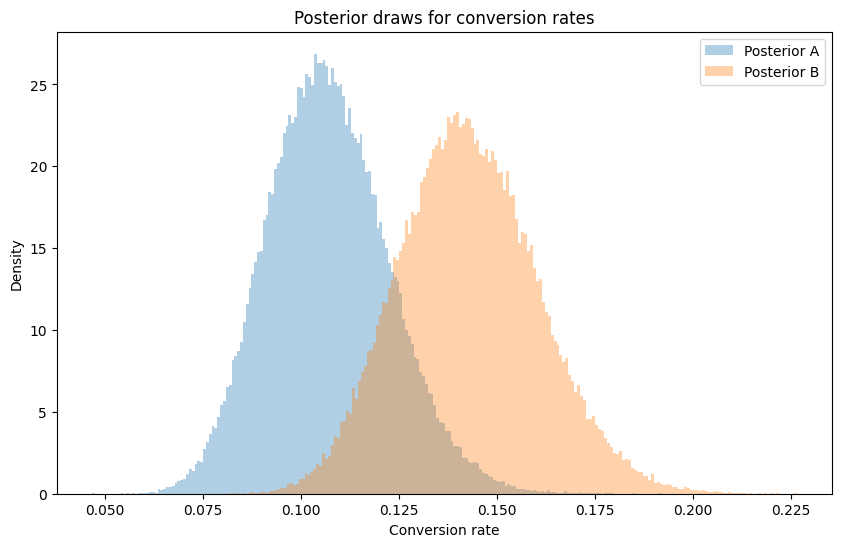

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(theta_A_draw_exact, bins=200, density=True, alpha=0.35, label="Posterior A")
plt.hist(theta_B_draw_exact, bins=200, density=True, alpha=0.35, label="Posterior B")
plt.xlabel("Conversion rate")
plt.ylabel("Density")
plt.title("Posterior draws for conversion rates")
plt.legend()
plt.show()

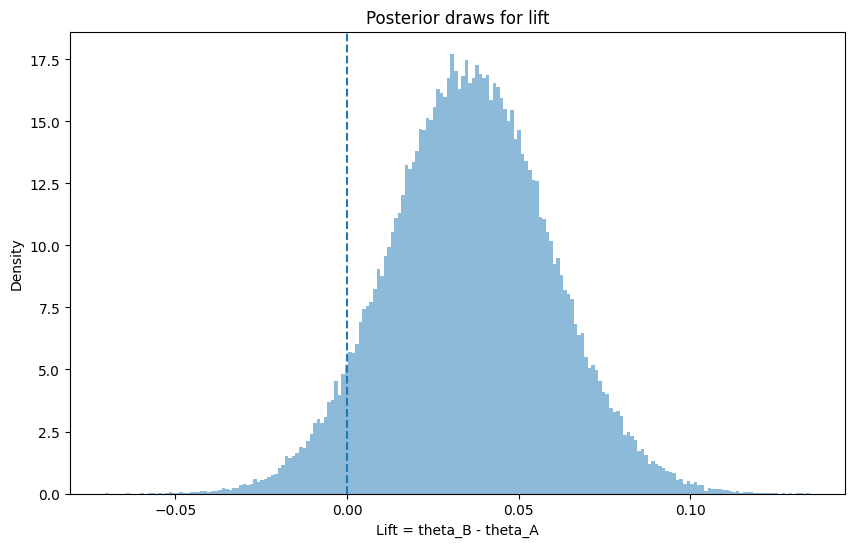

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(lift_draws_exact, bins=200, density=True, alpha=0.5)
plt.axvline(0, linestyle="--")
plt.xlabel("Lift = theta_B - theta_A")
plt.ylabel("Density")
plt.title("Posterior draws for lift")
plt.show()

In [22]:
with pm.Model() as ab_model: # starts bayesian model context
    # define priors
    theta_A = pm.Beta("theta_A", alpha=1, beta=1)
    theta_B = pm.Beta("theta_B", alpha=1, beta=1)

    # define likelihoods with observed data
    obs_A = pm.Binomial("obs_A", n=n_A, p=theta_A, observed=y_A)
    obs_B = pm.Binomial("obs_B", n=n_B, p=theta_B, observed=y_B)

    # store lift at every draw
    lift = pm.Deterministic("lift", theta_B - theta_A)

    # generate posterior draws
    trace_ab = pm.sample(
        2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta_A, theta_B]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


- posterior draws are a general representation of uncertainty

- MCMC is not always necessary, but it is still usable

- the same posterior-draw workflow can be reused across easy and hard models

In [23]:
az.summary(trace_ab, var_names=["theta_A", "theta_B", "lift"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_A,0.107,0.015,0.080,0.135,0.0,0.0,6020.0,5258.0,1.0
theta_B,0.143,0.018,0.111,0.178,0.0,0.0,5414.0,4636.0,1.0
lift,0.036,0.023,-0.007,0.080,0.0,0.0,5538.0,4580.0,1.0


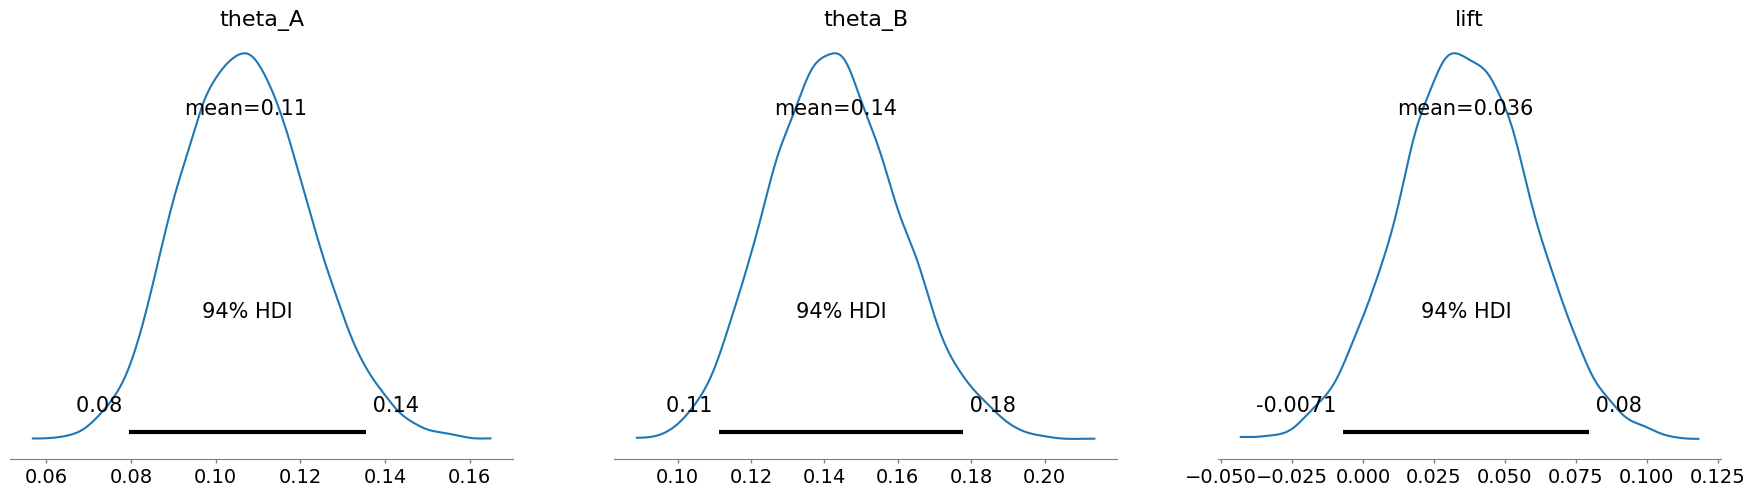

In [24]:
az.plot_posterior(trace_ab, var_names=["theta_A", "theta_B", "lift"])
plt.show()

In [25]:
theta_A_draws_pymc = trace_ab.posterior["theta_A"].values.flatten()
theta_B_draws_pymc = trace_ab.posterior["theta_B"].values.flatten()
lift_draws_pymc = trace_ab.posterior["lift"].values.flatten()

print("P(theta_B > theta_A | data):", np.mean(theta_B_draws_pymc > theta_A_draws_pymc))

P(theta_B > theta_A | data): 0.938375


## Nonconjugate example code

In [30]:
# small dataset

# let x be the avg time in minutes spent on the web page
# y is binary
# we want the probability of success to depend on x
x = np.array([1.0, 1.5, 1.0, 0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1])


In [32]:
# logistic regression model

with pm.Model() as logit_model:
    # priors - intercept, slope
    beta_0 = pm.Normal("beta_0", mu=0, sigma=5)
    beta_1 = pm.Normal("beta_1", mu=0, sigma=5)
    
    # linear predictor
    logit_p = beta_0 + beta_1 * x
    # logistic link, sigmoid takes real nums > probabilities between 0,1
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))
    
    # likelihood, bernoulli with probability p_1
    obs = pm.Bernoulli("obs", p=p, observed=y)
    
    # sampling
    trace_logit = pm.sample(
        2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_1]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


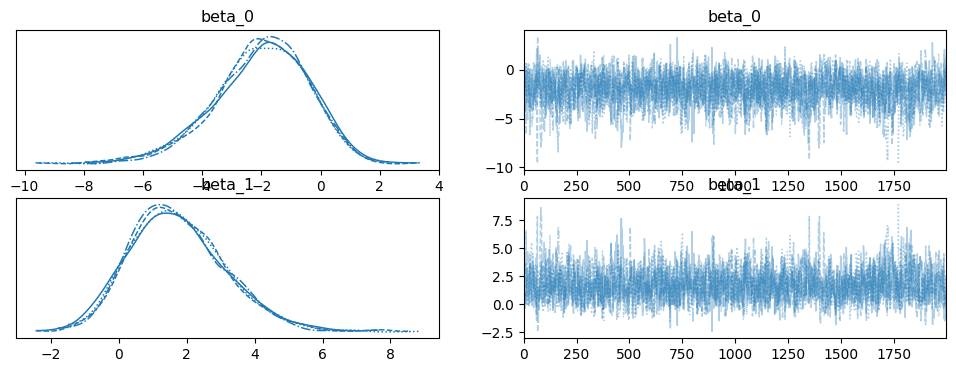

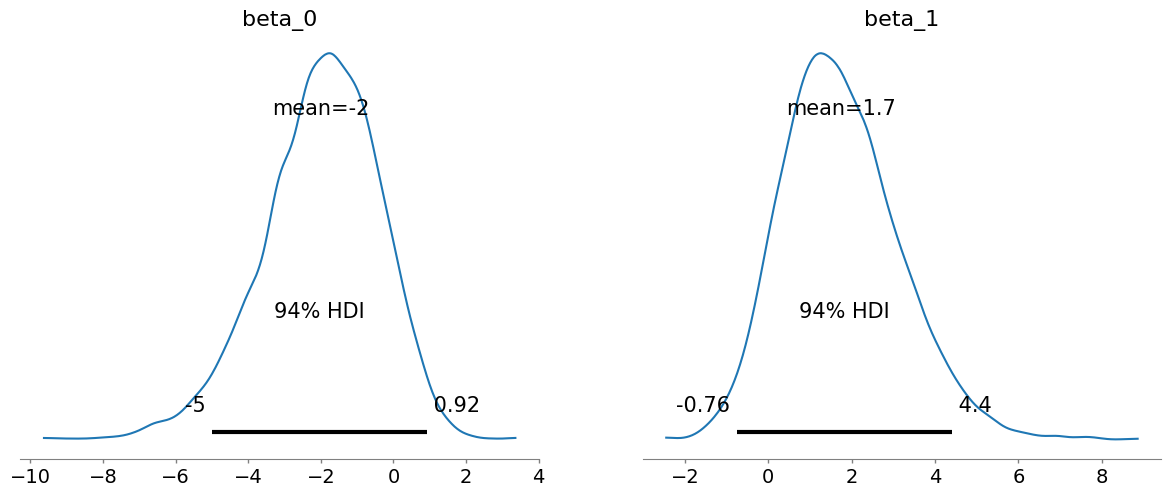

In [33]:
# summarize and interpret

az.summary(trace_logit, var_names=["beta_0", "beta_1"])

az.plot_trace(trace_logit, var_names=["beta_0", "beta_1"])
plt.show()

az.plot_posterior(trace_logit, var_names=["beta_0", "beta_1"])
plt.show()

In [36]:
# posterior draws for prediction

beta_0_draws = trace_logit.posterior["beta_0"].values.flatten()
beta_1_draws = trace_logit.posterior["beta_1"].values.flatten()

x_new = np.array([-1.0, 0.0, 1.0])

p_new_draws = []

for x_val in x_new:
    logit_vals = beta_0_draws + beta_1_draws * x_val
    p_vals = 1 /(1 + np.exp(-logit_vals))
    p_new_draws.append(p_vals)

In [37]:
for i, x_val in enumerate(x_new):
    mean_p = p_new_draws[i].mean()
    ci_p = np.quantile(p_new_draws[i], [0.025, 0.975])
    print(f"x = {x_val}: mean predicted p = {mean_p:.3f}, 95% CI = {ci_p}")

x = -1.0: mean predicted p = 0.129, 95% CI = [4.29576899e-05 7.60283349e-01]
x = 0.0: mean predicted p = 0.195, 95% CI = [0.00398288 0.67860156]
x = 1.0: mean predicted p = 0.442, 95% CI = [0.14089447 0.77601265]


- Now each element in p_new_draws is a full posterior distribution for a predicted probability at a given 𝑥